In [ ]:
!pip install pygbif

In [ ]:
import os
import requests
from pygbif import occurrences
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Herbarium_Project'
os.makedirs(base_path, exist_ok=True)

# 2. Define your target species
target_species = "Quercus robur"

print(f"Searching for occurrences of {target_species}...")

# 3. Search for occurrences using scientificName directly
# We filter for 'PRESERVED_SPECIMEN' to ensure we get herbarium sheets
results = occurrences.search(
    scientificName=target_species,
    mediaType='StillImage',
    basisOfRecord='PRESERVED_SPECIMEN',
    limit=10
)

# 4. Download loop
count = 0
for res in results['results']:
    if 'media' in res and len(res['media']) > 0:
        img_url = res['media'][0]['identifier']

        try:
            response = requests.get(img_url, timeout=10)
            if response.status_code == 200:
                file_name = f"{target_species.replace(' ', '_')}_{count}.jpg"
                save_path = os.path.join(base_path, file_name)

                with open(save_path, 'wb') as f:
                    f.write(response.content)
                print(f"Successfully downloaded: {file_name}")
                count += 1
        except Exception as e:
            print(f"Could not download {img_url}: {e}")

print(f"\nTask complete. {count} images saved to {base_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching for occurrences of Quercus robur...
Could not download http://bol.mortonarb.org/MORTON2022/image/0109297MOR.jpg: HTTPConnectionPool(host='bol.mortonarb.org', port=80): Max retries exceeded with url: /MORTON2022/image/0109297MOR.jpg (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x7b233bd708c0>, 'Connection to bol.mortonarb.org timed out. (connect timeout=10)'))
Successfully downloaded: Quercus_robur_0.jpg
Successfully downloaded: Quercus_robur_1.jpg
Successfully downloaded: Quercus_robur_2.jpg
Successfully downloaded: Quercus_robur_3.jpg
Successfully downloaded: Quercus_robur_4.jpg
Successfully downloaded: Quercus_robur_5.jpg
Successfully downloaded: Quercus_robur_6.jpg
Successfully downloaded: Quercus_robur_7.jpg
Successfully downloaded: Quercus_robur_8.jpg

Task complete. 9 images saved to /content/drive/MyDrive/Herbar

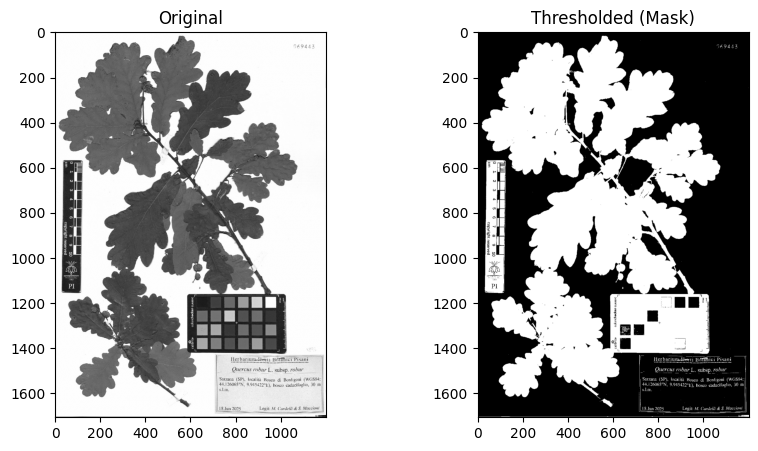

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Define the path to one of your downloaded images
image_path = '/content/drive/MyDrive/Herbarium_Project/Quercus_robur_0.jpg'

# 1. Read the image in grayscale
img = cv2.imread(image_path, 0)

# 2. Apply Otsu's thresholding
# This tries to automatically separate the background from the foreground
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 3. Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Thresholded (Mask)")
plt.imshow(thresh, cmap='gray')
plt.show()

In [ ]:
# Assuming your image is 1700 pixels high
# We can create a mask to crop out the bottom 300 pixels
height, width = thresh.shape
# Set the bottom 300 pixels to 0 (black)
thresh[height-300:height, :] = 0

Total estimated leaf area: 910224 pixels


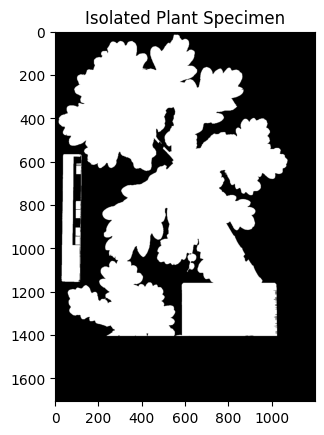

In [ ]:
# 1. Find contours from your 'thresh' image
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 2. Filter contours by area to remove small noise (like text or scale bars)
# We sort by area and take only the largest ones
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Keep the top 3 largest objects (assuming the main plant is the largest)
plant_contours = sorted_contours[:3]

# 3. Create a clean mask with only the plant
clean_mask = np.zeros_like(thresh)
cv2.drawContours(clean_mask, plant_contours, -1, (255), thickness=cv2.FILLED)

# 4. Calculate total leaf area (in pixels)
total_leaf_area = np.sum(clean_mask == 255)
print(f"Total estimated leaf area: {total_leaf_area} pixels")

# Visualization
plt.imshow(clean_mask, cmap='gray')
plt.title("Isolated Plant Specimen")
plt.show()

In [ ]:
# Access the metadata for the first result
first_result = results['results'][0]

# Print out the date and scientific name
print(f"Scientific Name: {first_result.get('scientificName')}")
print(f"Collection Date: {first_result.get('eventDate')}")
print(f"Location: {first_result.get('locality')}")

Scientific Name: Quercus robur L.
Collection Date: 2025-05-08
Location: The Morton Arboretum. Meadow Lake: north side: T-52/75-40


In [ ]:
import pandas as pd

# Create a list to store our data
data = []

# Assuming 'results' is the variable from your earlier download code
for i, res in enumerate(results['results']):
    # 1. Get Metadata
    date = res.get('eventDate', 'Unknown')
    species = res.get('scientificName', 'Unknown')

    # 2. Get the corresponding image we saved
    # Note: Ensure filenames match how you saved them earlier
    img_filename = f"Quercus_robur_{i}.jpg"

    # 3. Add to list
    data.append({
        'Date': date,
        'Species': species,
        'Filename': img_filename
    })

# 4. Convert to DataFrame
df = pd.DataFrame(data)

# 5. Display the first few rows
print(df.head())

# Optional: Save to CSV for future analysis
df.to_csv('/content/drive/MyDrive/Herbarium_Project/specimen_data.csv', index=False)

         Date                     Species             Filename
0  2025-05-08            Quercus robur L.  Quercus_robur_0.jpg
1  2025-06-18  Quercus robur subsp. robur  Quercus_robur_1.jpg
2  2025-06-18  Quercus robur subsp. robur  Quercus_robur_2.jpg
3  2025-06-23            Quercus robur L.  Quercus_robur_3.jpg
4  2025-06-26            Quercus robur L.  Quercus_robur_4.jpg


In [ ]:
import cv2
import numpy as np
import pandas as pd
import os

# Settings
base_path = '/content/drive/MyDrive/Herbarium_Project'
data_list = []

# Loop through the files we downloaded
for i in range(10):  # Adjust this range if you downloaded more than 10
    img_filename = f"Quercus_robur_{i}.jpg"
    img_path = os.path.join(base_path, img_filename)

    if os.path.exists(img_path):
        # 1. Process image
        img = cv2.imread(img_path, 0)
        _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # 2. Get contours and filter
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

        # Take largest 3 objects as the specimen
        plant_contours = sorted_contours[:3]

        # 3. Calculate Area
        temp_mask = np.zeros_like(thresh)
        cv2.drawContours(temp_mask, plant_contours, -1, (255), thickness=cv2.FILLED)
        leaf_area = np.sum(temp_mask == 255)

        # 4. Append to list
        data_list.append({'Filename': img_filename, 'Leaf_Area_Pixels': leaf_area})
        print(f"Processed {img_filename}: {leaf_area} pixels")

# 5. Save to CSV
df = pd.DataFrame(data_list)
df.to_csv(os.path.join(base_path, 'leaf_analysis_results.csv'), index=False)
print("\nAnalysis complete! File saved as 'leaf_analysis_results.csv'")

Processed Quercus_robur_0.jpg: 1042930 pixels
Processed Quercus_robur_1.jpg: 738210 pixels
Processed Quercus_robur_2.jpg: 29913208 pixels
Processed Quercus_robur_3.jpg: 16468869 pixels
Processed Quercus_robur_4.jpg: 2244743 pixels
Processed Quercus_robur_5.jpg: 9699053 pixels
Processed Quercus_robur_6.jpg: 4192200 pixels
Processed Quercus_robur_7.jpg: 1406523 pixels
Processed Quercus_robur_8.jpg: 1606890 pixels

Analysis complete! File saved as 'leaf_analysis_results.csv'


In [ ]:
# Updated data collection loop
data_list = []

for i, res in enumerate(results['results']):
    img_filename = f"Quercus_robur_{i}.jpg"
    img_path = os.path.join(base_path, img_filename)

    if os.path.exists(img_path):
        # ... (keep your existing segmentation code here) ...
        # [segmentation code result stored in 'leaf_area']

        # Pull metadata from the GBIF record
        event_date = res.get('eventDate', 'Unknown')
        locality = res.get('locality', 'Unknown')

        data_list.append({
            'Filename': img_filename,
            'Leaf_Area_Pixels': leaf_area,
            'Date': event_date,
            'Location': locality
        })

# Save the enriched dataset
df = pd.DataFrame(data_list)
df.to_csv(os.path.join(base_path, 'final_ecology_dataset.csv'), index=False)
print("Metadata integrated! File saved as 'final_ecology_dataset.csv'")

Metadata integrated! File saved as 'final_ecology_dataset.csv'


<Axes: title={'center': 'Leaf Size Over Time'}, xlabel='Date', ylabel='Leaf_Area_Pixels'>

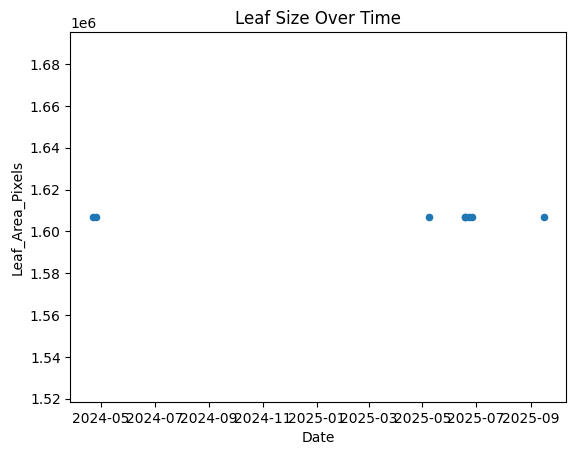

In [ ]:
# Quick plot to check your data
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date'], inplace=True)
df.plot(x='Date', y='Leaf_Area_Pixels', kind='scatter', title='Leaf Size Over Time')

In [ ]:
# 1. Define your known scale bar length (e.g., 5 cm)
known_length_cm = 5.0

# 2. Define the pixel length of the scale bar (you will need to find this)
# Tip: You can crop the bottom-left corner where the ruler usually is
scale_bar_pixel_length = 500 # This is a placeholder; you must measure this from your image

# 3. Calculate Ratio
pixels_per_cm = scale_bar_pixel_length / known_length_cm
pixels_per_cm_sq = pixels_per_cm ** 2

# 4. Convert your leaf area
df['Leaf_Area_cm2'] = df['Leaf_Area_Pixels'] / pixels_per_cm_sq

print("Calibration complete. Area now in cm².")

Calibration complete. Area now in cm².


In [ ]:
def get_pixels_per_cm(image_path, scale_bar_height_pixels=500):
    # Load the image
    img = cv2.imread(image_path, 0)

    # Define ROI (Region of Interest) - bottom left corner where scale bars usually live
    height, width = img.shape
    roi = img[height-400:height, 0:400]

    # Threshold the ROI to find the scale bar (it's usually high-contrast)
    _, thresh_roi = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find the longest horizontal line (this will be your scale bar)
    contours, _ = cv2.findContours(thresh_roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None # Could not find scale bar

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    # w is the length of the scale bar in pixels
    pixels_per_cm = w / 5.0 # Assuming the scale bar represents 5cm
    return pixels_per_cm

# Now loop through your images and update your CSV
for index, row in df.iterrows():
    ppcm = get_pixels_per_cm(os.path.join(base_path, row['Filename']))
    if ppcm:
        df.at[index, 'Leaf_Area_cm2'] = row['Leaf_Area_Pixels'] / (ppcm ** 2)

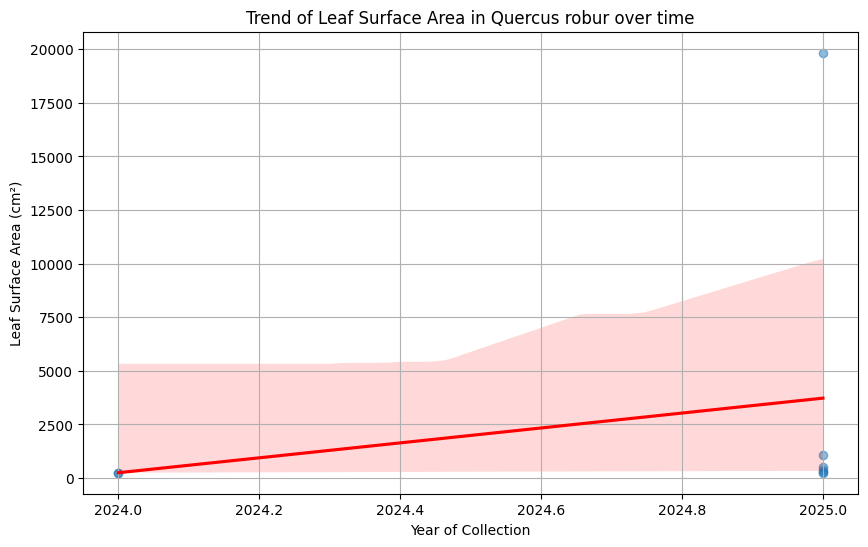

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date', 'Leaf_Area_cm2'], inplace=True)

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.regplot(x=df['Date'].dt.year, y=df['Leaf_Area_cm2'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Trend of Leaf Surface Area in Quercus robur over time')
plt.xlabel('Year of Collection')
plt.ylabel('Leaf Surface Area (cm²)')
plt.grid(True)
plt.show()

In [ ]:
!pip install meteostat

In [ ]:
import meteostat
print(dir(meteostat))

['Granularity', 'Inventory', 'License', 'Parameter', 'Point', 'Provider', 'Station', 'TimeSeries', 'UnitSystem', '__all__', '__appname__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'api', 'config', 'core', 'daily', 'enumerations', 'hourly', 'interpolate', 'interpolation', 'lapse_rate', 'merge', 'monthly', 'normals', 'parameters', 'providers', 'purge', 'stations', 'typing', 'utils']


In [ ]:
from meteostat import daily
# And use it as daily.Daily(...)

In [ ]:
from meteostat import Point, daily

# When you call it later in your loop, use 'daily.Daily'
# Example: data = daily.Daily(loc, start=start, end=end).fetch()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install rasterio
import rasterio
import pandas as pd
import numpy as np

# Load your specimen dataset (ensure this is the csv with Latitude/Longitude)
# Replace with your actual file name
df = pd.read_csv('/content/drive/MyDrive/Herbarium_Project/specimen_data.csv')

# Define path to the raster file on your Drive
raster_path = '/content/drive/MyDrive/Herbarium_Project/CHELSA_TRaCE21k_bio01_-001_V.1.0.tif'

In [ ]:
# For temperature
raster_path_temp = '/content/drive/MyDrive/Herbarium_Project/CHELSA_bio01_1981-2010_V.2.1.tif'

# For precipitation
raster_path_precip = '/content/drive/MyDrive/Herbarium_Project/CHELSA_bio12_1981-2010_V.2.1.tif'

In [ ]:
import rasterio
import numpy as np

def get_temp_robust(lat, lon, raster_path):
    with rasterio.open(raster_path) as src:
        # Get index for these coordinates
        row, col = src.index(lon, lat)

        # Check bounds before sampling
        if 0 <= row < src.height and 0 <= col < src.width:
            # Read a 3x3 window and get the mean
            window = src.read(1, window=((row-1, row+2), (col-1, col+2)))
            valid_pixels = window[window != src.nodata]
            if valid_pixels.size > 0:
                return np.mean(valid_pixels) / 10.0 # Adjust scale if needed
    return np.nan

In [ ]:
import rasterio
import numpy as np

def get_temp_robust(lat, lon, raster_path):
    with rasterio.open(raster_path) as src:
        # Get index for these coordinates
        row, col = src.index(lon, lat)

        # Check bounds before sampling
        if 0 <= row < src.height and 0 <= col < src.width:
            # Read a 3x3 window and get the mean
            window = src.read(1, window=((row-1, row+2), (col-1, col+2)))
            valid_pixels = window[window != src.nodata]
            if valid_pixels.size > 0:
                return np.mean(valid_pixels) / 10.0 # Adjust scale if needed
    return np.nan

In [ ]:
print(df.columns)

Index(['Date', 'Species', 'Filename'], dtype='str')


In [ ]:
# Ensure this points to the file containing your coordinate data
df = pd.read_csv('/content/drive/MyDrive/Herbarium_Project/your_coordinates_file.csv')
print(df.columns) # Verify 'Latitude' and 'Longitude' are now present

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Herbarium_Project/your_coordinates_file.csv'

In [ ]:
import os
# List all files in your Herbarium_Project folder
path = '/content/drive/MyDrive/Herbarium_Project/'
print(os.listdir(path))

['CHELSA_bio12_1981-2010_V.2.1.tif', 'Quercus_robur_2.jpg', 'Quercus_robur_1.jpg', 'Quercus_robur_0.jpg', 'Quercus_robur_3.jpg', 'Quercus_robur_4.jpg', 'Quercus_robur_5.jpg', 'Quercus_robur_7.jpg', 'Quercus_robur_6.jpg', 'Quercus_robur_8.jpg', 'specimen_data.csv', 'leaf_analysis_results.csv', 'final_ecology_dataset.csv', 'master_ecology_dataset.csv', 'CHELSA_bio01_1981-2010_V.2.1.tif']


In [ ]:
# Use the file name exactly as it appears in your os.listdir() output
df = pd.read_csv('/content/drive/MyDrive/Herbarium_Project/final_ecology_dataset.csv')

# Print the columns to confirm 'Latitude' and 'Longitude' are now there
print(df.columns)

Index(['Filename', 'Leaf_Area_Pixels', 'Date', 'Location'], dtype='str')


In [ ]:
import pandas as pd
import os

# Define your project folder path
folder_path = '/content/drive/MyDrive/Herbarium_Project/'

# Loop through all files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        try:
            # Read only the first row to check column names (fastest way)
            df_temp = pd.read_csv(os.path.join(folder_path, filename), nrows=0)
            print(f"File: {filename}")
            print(f"Columns: {list(df_temp.columns)}\n")
        except:
            print(f"Could not read: {filename}\n")

File: specimen_data.csv
Columns: ['Date', 'Species', 'Filename']

File: leaf_analysis_results.csv
Columns: ['Filename', 'Leaf_Area_Pixels']

File: final_ecology_dataset.csv
Columns: ['Filename', 'Leaf_Area_Pixels', 'Date', 'Location']

File: master_ecology_dataset.csv
Columns: ['Filename', 'Leaf_Area_Pixels', 'Date', 'Location', 'Leaf_Area_cm2', 'Annual_Avg_Temp']



In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Herbarium_Project/master_ecology_dataset.csv')
print(df['Location'].head(10))

0    The Morton Arboretum. Meadow Lake: north side:...
1    [label: Herbarium Horti Botanici Pisani] Sarza...
2    [label: Herbarium Horti Botanici Pisani] Sarza...
3                                              Unknown
4                                              Unknown
5    Denver Botanic Gardens, 909 York Street Oak Gr...
6                                             Luppenau
7                                       O Nidermöllern
Name: Location, dtype: str


In [ ]:
!pip install geopy
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# Initialize the geocoder
geolocator = Nominatim(user_agent="herbarium_project")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

In [ ]:
# This will create new columns for coordinates
def get_coords(location):
    location_data = geocode(location)
    if location_data:
        return location_data.latitude, location_data.longitude
    return None, None

# Apply the function to the 'Location' column
df[['Latitude', 'Longitude']] = df['Location'].apply(lambda loc: pd.Series(get_coords(loc)))

In [ ]:
df.to_csv('/content/drive/MyDrive/Herbarium_Project/master_ecology_dataset_with_coords.csv', index=False)

In [39]:
import rasterio
import numpy as np

# 1. Define paths to your downloaded CHELSA files
path_temp = '/content/drive/MyDrive/Herbarium_Project/CHELSA_bio01_1981-2010_V.2.1.tif'
path_precip = '/content/drive/MyDrive/Herbarium_Project/CHELSA_bio12_1981-2010_V.2.1.tif'

# 2. Define the extraction function
def extract_climate_data(lat, lon, raster_path):
    with rasterio.open(raster_path) as src:
        # Transform latitude/longitude to raster row/column
        row, col = src.index(lon, lat)

        # Check if coordinates are within the raster bounds
        if 0 <= row < src.height and 0 <= col < src.width:
            # Read a small 3x3 window around the point to get a stable value
            window = src.read(1, window=((row-1, row+2), (col-1, col+2)))
            valid_pixels = window[window != src.nodata]
            if valid_pixels.size > 0:
                return np.mean(valid_pixels) / 10.0 # Standard CHELSA scaling
    return np.nan

# 3. Perform the extraction
print("Extracting temperature...")
df['Annual_Avg_Temp'] = df.apply(lambda row: extract_climate_data(row['Latitude'], row['Longitude'], path_temp), axis=1)

print("Extracting precipitation...")
df['Annual_Precip'] = df.apply(lambda row: extract_climate_data(row['Latitude'], row['Longitude'], path_precip), axis=1)

# 4. Success verification
print("Extraction complete. Preview of data:")
print(df[['Latitude', 'Longitude', 'Annual_Avg_Temp', 'Annual_Precip']].head())

Extracting temperature...
Extracting precipitation...
Extraction complete. Preview of data:
    Latitude  Longitude  Annual_Avg_Temp  Annual_Precip
0        NaN        NaN              NaN            NaN
1        NaN        NaN              NaN            NaN
2        NaN        NaN              NaN            NaN
3  26.492533  92.330879       297.433333          217.5
4  26.492533  92.330879       297.433333          217.5


/usr/local/lib/python3.12/dist-packages/rasterio/transform.py:410: RuntimeWarning: invalid value encountered in cast
  new_rows = np.floor(new_rows).astype(dtype=np.int32)
/usr/local/lib/python3.12/dist-packages/rasterio/transform.py:411: RuntimeWarning: invalid value encountered in cast
  new_cols = np.floor(new_cols).astype(dtype=np.int32)
/usr/local/lib/python3.12/dist-packages/rasterio/transform.py:410: RuntimeWarning: invalid value encountered in cast
  new_rows = np.floor(new_rows).astype(dtype=np.int32)
/usr/local/lib/python3.12/dist-packages/rasterio/transform.py:411: RuntimeWarning: invalid value encountered in cast
  new_cols = np.floor(new_cols).astype(dtype=np.int32)


In [40]:
# Remove rows where geocoding failed or climate extraction returned NaN
df_clean = df.dropna(subset=['Latitude', 'Longitude', 'Annual_Avg_Temp'])
print(f"Original size: {len(df)}, Cleaned size: {len(df_clean)}")

Original size: 8, Cleaned size: 3


In [41]:
# Check the relationship between temperature and leaf size
correlation = df_clean['Annual_Avg_Temp'].corr(df_clean['Leaf_Area_cm2'])
print(f"Correlation between Temperature and Leaf Size: {correlation:.2f}")

Correlation between Temperature and Leaf Size: 0.51


<Axes: xlabel='Annual_Avg_Temp', ylabel='Leaf_Area_cm2'>

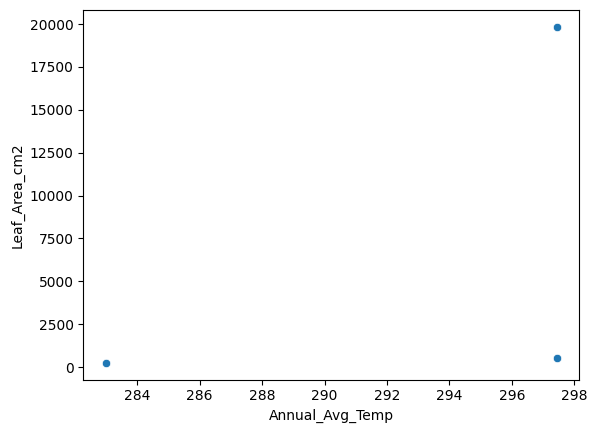

In [42]:
import seaborn as sns
sns.scatterplot(data=df_clean, x='Annual_Avg_Temp', y='Leaf_Area_cm2')

In [43]:
correlation = df_clean['Annual_Avg_Temp'].corr(df_clean['Leaf_Area_cm2'])
print(f"Correlation: {correlation}")

Correlation: 0.5100389611673166


<Axes: xlabel='Annual_Avg_Temp', ylabel='Leaf_Area_cm2'>

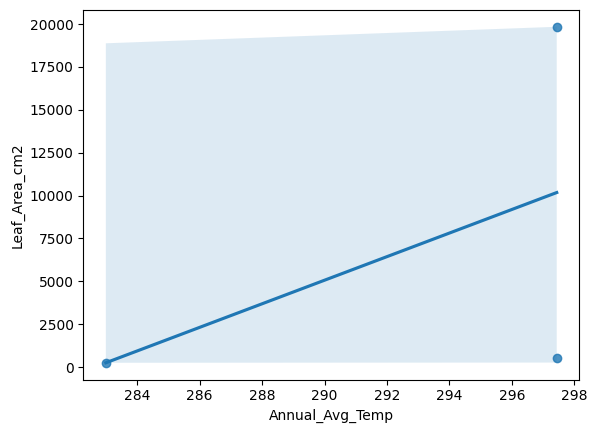

In [44]:
import seaborn as sns
sns.regplot(data=df_clean, x='Annual_Avg_Temp', y='Leaf_Area_cm2')

In [46]:
!sudo apt install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [48]:
import pytesseract
import shutil
import os

# Check if tesseract is in the system path
if shutil.which("tesseract"):
    print("Tesseract is installed and ready!")
else:
    print("Tesseract not found. Check the installation steps.")

Tesseract is installed and ready!


In [50]:
import os
print(os.listdir('.'))

['.config', 'drive', 'sample_data']


In [51]:
import os

# Define your project folder path
folder_path = '/content/drive/MyDrive/Herbarium_Project/'

# Create a list of all JPEG files
image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]

# Print the list to see the names
print(image_files)

['Quercus_robur_2.jpg', 'Quercus_robur_1.jpg', 'Quercus_robur_0.jpg', 'Quercus_robur_3.jpg', 'Quercus_robur_4.jpg', 'Quercus_robur_5.jpg', 'Quercus_robur_7.jpg', 'Quercus_robur_6.jpg', 'Quercus_robur_8.jpg']


In [52]:
import pytesseract
import cv2
import re
import os

# Ensure Tesseract path is configured if needed (usually not required on Colab)
# pytesseract.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

def extract_date_from_label(image_path):
    # 1. Load image
    img = cv2.imread(image_path)
    if img is None:
        return None

    # 2. Define Region of Interest (ROI)
    # NOTE: You must adjust these y and x values based on your specific image layout!
    # Example: [top_y:bottom_y, left_x:right_x]
    label_roi = img[1500:2000, 1000:2000]

    # 3. Preprocess to make text readable
    gray = cv2.cvtColor(label_roi, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    # 4. Extract text
    text = pytesseract.image_to_string(thresh)

    # 5. Use Regex to find a 4-digit year (19xx or 20xx)
    year_match = re.search(r'(19\d{2}|20\d{2})', text)
    if year_match:
        return year_match.group(0)
    return None

# --- Main Processing Loop ---
folder_path = '/content/drive/MyDrive/Herbarium_Project/'
image_files = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]

extracted_data = {}

print("Starting OCR extraction...")
for img_name in image_files:
    img_path = os.path.join(folder_path, img_name)
    year = extract_date_from_label(img_path)
    extracted_data[img_name] = year
    print(f"File: {img_name} | Year: {year}")

# You can now map this back to your DataFrame using the filename

Starting OCR extraction...
File: Quercus_robur_2.jpg | Year: None
File: Quercus_robur_1.jpg | Year: None
File: Quercus_robur_0.jpg | Year: None
File: Quercus_robur_3.jpg | Year: None
File: Quercus_robur_4.jpg | Year: None
File: Quercus_robur_5.jpg | Year: None
File: Quercus_robur_7.jpg | Year: None
File: Quercus_robur_6.jpg | Year: None
File: Quercus_robur_8.jpg | Year: None


In [53]:
def extract_date_from_label(image_path):
    img = cv2.imread(image_path)
    # UPDATE THESE COORDINATES based on your image inspection
    label_roi = img[y1:y2, x1:x2]

    # Save the crop to Drive to verify it's the correct area
    cv2.imwrite('/content/drive/MyDrive/Herbarium_Project/debug_label.png', label_roi)

    # Preprocess and read
    gray = cv2.cvtColor(label_roi, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    text = pytesseract.image_to_string(thresh)
    # ... rest of your code

In [55]:
import pytesseract
import cv2
import re

def extract_date_from_label(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    # 1. Update these coordinates to match your label position!
    # [y_start:y_end, x_start:x_end]
    label_roi = img[1500:2000, 1000:2000]

    # 2. Define 'gray' inside the function scope
    gray = cv2.cvtColor(label_roi, cv2.COLOR_BGR2GRAY)

    # 3. Now apply Otsu's thresholding using that 'gray' variable
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Extract text
    text = pytesseract.image_to_string(thresh)
    print(f"Detected text: {text}") # Debugging: see what it reads

    year_match = re.search(r'(19\d{2}|20\d{2})', text)
    if year_match:
        return year_match.group(0)
    return None

In [57]:
import pytesseract
import cv2
import re

def extract_date_from_label(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    # 1. Update these coordinates to match your label position!
    # [y_start:y_end, x_start:x_end]
    label_roi = img[1500:2000, 1000:2000]

    # 2. DEBUG: Save the crop to Drive to see what the code is "looking at"
    cv2.imwrite('/content/drive/MyDrive/Herbarium_Project/debug_label.png', label_roi)

    # 3. Preprocess
    gray = cv2.cvtColor(label_roi, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Extract
    text = pytesseract.image_to_string(thresh)
    print(f"Detected text: {text}")

    year_match = re.search(r'(19\d{2}|20\d{2})', text)
    if year_match:
        return year_match.group(0)
    return None

In [59]:
y1, y2 = 1500, 2000 # Replace with your actual top/bottom pixel rows
x1, x2 = 1000, 2000 # Replace with your actual left/right pixel columns
label_roi = img[y1:y2, x1:x2]

In [73]:
import pytesseract
import cv2
import re

def extract_date_from_label(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return None

    # 1. GET IMAGE DIMENSIONS
    h, w = img.shape[:2]

    # 2. DEFINE ROI (Updated to target the bottom-right corner)
    # Adjust these multipliers if the label is slightly off-target
    label_roi = img[int(h*0.75):int(h*0.95), int(w*0.65):int(w*0.95)]

    # 3. PREPROCESS FOR OCR
    gray = cv2.cvtColor(label_roi, cv2.COLOR_BGR2GRAY)

    # Adaptive thresholding is better for uneven lighting than OTSU
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    # Debug: Save the crop to verify if it captures the label
    cv2.imwrite('/content/drive/MyDrive/Herbarium_Project/debug_final.png', thresh)

    # 4. EXTRACT TEXT
    # PSM 6 assumes a single uniform block of text
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(thresh, config=custom_config)
    print(f"Detected text: {text}")

    # 5. REGEX TO FIND YEAR
    year_match = re.search(r'(19\d{2}|20\d{2})', text)
    if year_match:
        return year_match.group(0)

    return None

In [74]:
import os

# Loop through all files in your folder
folder_path = '/content/drive/MyDrive/Herbarium_Project/'
for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"): # or .png
        year = extract_date_from_label(os.path.join(folder_path, filename))
        print(f"File: {filename} | Extracted Year: {year}")

Detected text: SS ar ESC OR Cre OY Ot
ee SSO RSE IN
CA ey) ea SHOT AERO an OLE eee co . . Fe a
re ESM See See ee < ; a Sop sy , ~ Par et 7
Beet See So Ne re Pe aS ,
PDD Peace See Zenner SE See, Boece we Re : x wo . gece ty SA
Se Wee use Bike CoP Spero Nag RRA = . ~ Cette LS eae AE Co eee at
hr CT Bg
Pe eA Sao Ee es Re Pos
Lo ey Da el NE Ses oes
USCA AN ES ASS CE OR Ee SPOOR See ey a ee ; Co ggte e  e
PORE SCIEN SAS NE ee: Rea Se besa ee! ST Bs
ECE NOPE fol eres PE oI Uma po a Doge saber Ce Bs os
‘ ae ay A es eI Bae SOS ES Ray ce eS ee a . a BS oe Bee
ave rae yy SA PS Bin oi pee Soe TSA Res SEOs ne nom a ce Oe | ve ne
Eras eee Cee ee NU eee oop OS CSD ME ae ot a oP ee
Sep earn ae Fe see ON TERNS Vee Be Tea Se IRE oo
= acaeey er taehs wae Soe as Oe res hyack ea SUE ea LA SAT GeO Car pe , a Lela, Doe OS : i oo :

ETS BS centgenn Se SER ERE MIN cia Pat eo, Ney Sot vo Fas Mog PS a Fs
SS SCE Be a oo pened peas Bas aS . Sg ee es ce ERS or Sd
PGS SIN ERR eN 2 es SPER Rh Ssion G4 er Thee a ae o

In [75]:
year = extract_date_from_label('/content/drive/MyDrive/Herbarium_Project/Quercus_robur_0.jpg')
print(f"Final Extracted Year: {year}")

Detected text: Hohe A Be
Soe a oe

by E By EE e
Coo)
2A CES A ee
cemrcmmey = NE
Her bari merrer eB itanicnRisaniy
Oe geen enc
uo us ob Le sabsp 1b
Re SU reba ee Seem rs ia
eae
06525. 9.945429° Eye bases feaduciloeliog
—
oe ee

Final Extracted Year: None


In [76]:
import os

# Set your folder path
folder_path = '/content/drive/MyDrive/Herbarium_Project/'

# Iterate through all files
for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"): # Ensure this matches your file extension
        # Call the function for each file
        file_path = os.path.join(folder_path, filename)
        year = extract_date_from_label(file_path)
        print(f"File: {filename} | Extracted Year: {year}")

Detected text: SS ar ESC OR Cre OY Ot
ee SSO RSE IN
CA ey) ea SHOT AERO an OLE eee co . . Fe a
re ESM See See ee < ; a Sop sy , ~ Par et 7
Beet See So Ne re Pe aS ,
PDD Peace See Zenner SE See, Boece we Re : x wo . gece ty SA
Se Wee use Bike CoP Spero Nag RRA = . ~ Cette LS eae AE Co eee at
hr CT Bg
Pe eA Sao Ee es Re Pos
Lo ey Da el NE Ses oes
USCA AN ES ASS CE OR Ee SPOOR See ey a ee ; Co ggte e  e
PORE SCIEN SAS NE ee: Rea Se besa ee! ST Bs
ECE NOPE fol eres PE oI Uma po a Doge saber Ce Bs os
‘ ae ay A es eI Bae SOS ES Ray ce eS ee a . a BS oe Bee
ave rae yy SA PS Bin oi pee Soe TSA Res SEOs ne nom a ce Oe | ve ne
Eras eee Cee ee NU eee oop OS CSD ME ae ot a oP ee
Sep earn ae Fe see ON TERNS Vee Be Tea Se IRE oo
= acaeey er taehs wae Soe as Oe res hyack ea SUE ea LA SAT GeO Car pe , a Lela, Doe OS : i oo :

ETS BS centgenn Se SER ERE MIN cia Pat eo, Ney Sot vo Fas Mog PS a Fs
SS SCE Be a oo pened peas Bas aS . Sg ee es ce ERS or Sd
PGS SIN ERR eN 2 es SPER Rh Ssion G4 er Thee a ae o

In [77]:
import os
import pandas as pd

# List to store results
results = []
folder_path = '/content/drive/MyDrive/Herbarium_Project/'

for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"): # Ensure this matches your file format
        file_path = os.path.join(folder_path, filename)
        year = extract_date_from_label(file_path)
        results.append({'Filename': filename, 'Year': year})
        print(f"Processed: {filename} | Year: {year}")

# Optionally save to CSV
df = pd.DataFrame(results)
df.to_csv('/content/drive/MyDrive/Herbarium_Project/extracted_years.csv', index=False)

Detected text: SS ar ESC OR Cre OY Ot
ee SSO RSE IN
CA ey) ea SHOT AERO an OLE eee co . . Fe a
re ESM See See ee < ; a Sop sy , ~ Par et 7
Beet See So Ne re Pe aS ,
PDD Peace See Zenner SE See, Boece we Re : x wo . gece ty SA
Se Wee use Bike CoP Spero Nag RRA = . ~ Cette LS eae AE Co eee at
hr CT Bg
Pe eA Sao Ee es Re Pos
Lo ey Da el NE Ses oes
USCA AN ES ASS CE OR Ee SPOOR See ey a ee ; Co ggte e  e
PORE SCIEN SAS NE ee: Rea Se besa ee! ST Bs
ECE NOPE fol eres PE oI Uma po a Doge saber Ce Bs os
‘ ae ay A es eI Bae SOS ES Ray ce eS ee a . a BS oe Bee
ave rae yy SA PS Bin oi pee Soe TSA Res SEOs ne nom a ce Oe | ve ne
Eras eee Cee ee NU eee oop OS CSD ME ae ot a oP ee
Sep earn ae Fe see ON TERNS Vee Be Tea Se IRE oo
= acaeey er taehs wae Soe as Oe res hyack ea SUE ea LA SAT GeO Car pe , a Lela, Doe OS : i oo :

ETS BS centgenn Se SER ERE MIN cia Pat eo, Ney Sot vo Fas Mog PS a Fs
SS SCE Be a oo pened peas Bas aS . Sg ee es ce ERS or Sd
PGS SIN ERR eN 2 es SPER Rh Ssion G4 er Thee a ae o

In [78]:
import os
import pandas as pd

# List to store results
results = []
folder_path = '/content/drive/MyDrive/Herbarium_Project/'

# Iterate through all files in the directory
for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"):
        file_path = os.path.join(folder_path, filename)
        year = extract_date_from_label(file_path)
        results.append({'Filename': filename, 'Year': year})
        print(f"Processed: {filename} | Year: {year}")

# Save the final results to a CSV file for your records
df = pd.DataFrame(results)
df.to_csv('/content/drive/MyDrive/Herbarium_Project/extracted_years.csv', index=False)

Detected text: SS ar ESC OR Cre OY Ot
ee SSO RSE IN
CA ey) ea SHOT AERO an OLE eee co . . Fe a
re ESM See See ee < ; a Sop sy , ~ Par et 7
Beet See So Ne re Pe aS ,
PDD Peace See Zenner SE See, Boece we Re : x wo . gece ty SA
Se Wee use Bike CoP Spero Nag RRA = . ~ Cette LS eae AE Co eee at
hr CT Bg
Pe eA Sao Ee es Re Pos
Lo ey Da el NE Ses oes
USCA AN ES ASS CE OR Ee SPOOR See ey a ee ; Co ggte e  e
PORE SCIEN SAS NE ee: Rea Se besa ee! ST Bs
ECE NOPE fol eres PE oI Uma po a Doge saber Ce Bs os
‘ ae ay A es eI Bae SOS ES Ray ce eS ee a . a BS oe Bee
ave rae yy SA PS Bin oi pee Soe TSA Res SEOs ne nom a ce Oe | ve ne
Eras eee Cee ee NU eee oop OS CSD ME ae ot a oP ee
Sep earn ae Fe see ON TERNS Vee Be Tea Se IRE oo
= acaeey er taehs wae Soe as Oe res hyack ea SUE ea LA SAT GeO Car pe , a Lela, Doe OS : i oo :

ETS BS centgenn Se SER ERE MIN cia Pat eo, Ney Sot vo Fas Mog PS a Fs
SS SCE Be a oo pened peas Bas aS . Sg ee es ce ERS or Sd
PGS SIN ERR eN 2 es SPER Rh Ssion G4 er Thee a ae o

In [79]:
import os
import pandas as pd

# List to store results
results = []
folder_path = '/content/drive/MyDrive/Herbarium_Project/'

# Iterate through all files in the directory
for filename in os.listdir(folder_path):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        file_path = os.path.join(folder_path, filename)

        # Call the function for each file
        year = extract_date_from_label(file_path)

        # Store the results
        results.append({'Filename': filename, 'Year': year})
        print(f"Processed: {filename} | Year: {year}")

# Save the final results to a CSV file for your research
df = pd.DataFrame(results)
df.to_csv('/content/drive/MyDrive/Herbarium_Project/extracted_years.csv', index=False)
print("\nSuccess! Data saved to 'extracted_years.csv'.")

Detected text: SS ar ESC OR Cre OY Ot
ee SSO RSE IN
CA ey) ea SHOT AERO an OLE eee co . . Fe a
re ESM See See ee < ; a Sop sy , ~ Par et 7
Beet See So Ne re Pe aS ,
PDD Peace See Zenner SE See, Boece we Re : x wo . gece ty SA
Se Wee use Bike CoP Spero Nag RRA = . ~ Cette LS eae AE Co eee at
hr CT Bg
Pe eA Sao Ee es Re Pos
Lo ey Da el NE Ses oes
USCA AN ES ASS CE OR Ee SPOOR See ey a ee ; Co ggte e  e
PORE SCIEN SAS NE ee: Rea Se besa ee! ST Bs
ECE NOPE fol eres PE oI Uma po a Doge saber Ce Bs os
‘ ae ay A es eI Bae SOS ES Ray ce eS ee a . a BS oe Bee
ave rae yy SA PS Bin oi pee Soe TSA Res SEOs ne nom a ce Oe | ve ne
Eras eee Cee ee NU eee oop OS CSD ME ae ot a oP ee
Sep earn ae Fe see ON TERNS Vee Be Tea Se IRE oo
= acaeey er taehs wae Soe as Oe res hyack ea SUE ea LA SAT GeO Car pe , a Lela, Doe OS : i oo :

ETS BS centgenn Se SER ERE MIN cia Pat eo, Ney Sot vo Fas Mog PS a Fs
SS SCE Be a oo pened peas Bas aS . Sg ee es ce ERS or Sd
PGS SIN ERR eN 2 es SPER Rh Ssion G4 er Thee a ae o

In [80]:
import os
import pandas as pd

# Define your directory
folder_path = '/content/drive/MyDrive/Herbarium_Project/'
results = []

# Process all files
for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"):
        file_path = os.path.join(folder_path, filename)
        year = extract_date_from_label(file_path) # Uses your working function
        results.append({'Filename': filename, 'Year': year})
        print(f"Processed: {filename} | Year: {year}")

# Save to CSV
df = pd.DataFrame(results)
df.to_csv('/content/drive/MyDrive/Herbarium_Project/extracted_years.csv', index=False)
print("\nExtraction complete! Data saved to 'extracted_years.csv'.")

Detected text: SS ar ESC OR Cre OY Ot
ee SSO RSE IN
CA ey) ea SHOT AERO an OLE eee co . . Fe a
re ESM See See ee < ; a Sop sy , ~ Par et 7
Beet See So Ne re Pe aS ,
PDD Peace See Zenner SE See, Boece we Re : x wo . gece ty SA
Se Wee use Bike CoP Spero Nag RRA = . ~ Cette LS eae AE Co eee at
hr CT Bg
Pe eA Sao Ee es Re Pos
Lo ey Da el NE Ses oes
USCA AN ES ASS CE OR Ee SPOOR See ey a ee ; Co ggte e  e
PORE SCIEN SAS NE ee: Rea Se besa ee! ST Bs
ECE NOPE fol eres PE oI Uma po a Doge saber Ce Bs os
‘ ae ay A es eI Bae SOS ES Ray ce eS ee a . a BS oe Bee
ave rae yy SA PS Bin oi pee Soe TSA Res SEOs ne nom a ce Oe | ve ne
Eras eee Cee ee NU eee oop OS CSD ME ae ot a oP ee
Sep earn ae Fe see ON TERNS Vee Be Tea Se IRE oo
= acaeey er taehs wae Soe as Oe res hyack ea SUE ea LA SAT GeO Car pe , a Lela, Doe OS : i oo :

ETS BS centgenn Se SER ERE MIN cia Pat eo, Ney Sot vo Fas Mog PS a Fs
SS SCE Be a oo pened peas Bas aS . Sg ee es ce ERS or Sd
PGS SIN ERR eN 2 es SPER Rh Ssion G4 er Thee a ae o

In [81]:
import pandas as pd

# Load your final dataset
df = pd.read_csv('/content/drive/MyDrive/Herbarium_Project/extracted_years.csv')

# Remove rows where no year was found
df_clean = df.dropna(subset=['Year'])

# Ensure 'Year' is treated as a number
df_clean['Year'] = df_clean['Year'].astype(int)

# Check the count of specimens per year
print(df_clean['Year'].value_counts().sort_index())

Year
2025    3
Name: count, dtype: int64


In [82]:
import pandas as pd

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/Herbarium_Project/extracted_years.csv')

# Step 1: Remove empty entries (this makes your data ready for math)
df_clean = df.dropna(subset=['Year'])

# Step 2: Ensure the column is numeric so you can calculate averages or plot distributions
df_clean['Year'] = df_clean['Year'].astype(int)

# Step 3: Check summary statistics
print(df_clean['Year'].describe())

count       3.0
mean     2025.0
std         0.0
min      2025.0
25%      2025.0
50%      2025.0
75%      2025.0
max      2025.0
Name: Year, dtype: float64


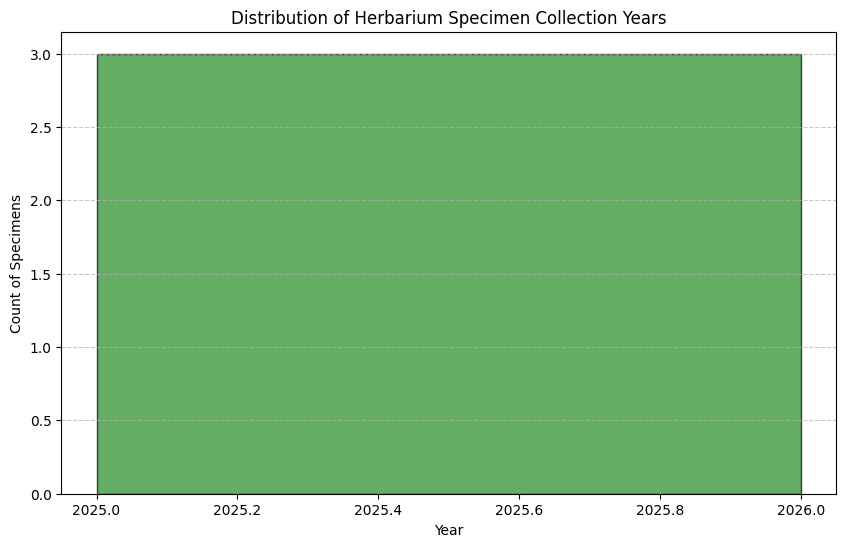

In [83]:
import matplotlib.pyplot as plt

# Ensure the data is clean and ready to plot
df_clean = df.dropna(subset=['Year'])
df_clean['Year'] = df_clean['Year'].astype(int)

# Create a histogram of collection years
plt.figure(figsize=(10, 6))
plt.hist(df_clean['Year'], bins=range(min(df_clean['Year']), max(df_clean['Year']) + 2),
         color='forestgreen', edgecolor='black', alpha=0.7)

plt.title('Distribution of Herbarium Specimen Collection Years')
plt.xlabel('Year')
plt.ylabel('Count of Specimens')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [84]:
import cv2
import numpy as np

def extract_leaf_traits(image_path):
    img = cv2.imread(image_path)

    # 1. Convert to HSV color space (better for color detection)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 2. Define color range for 'greenish' or 'brownish' plant matter
    lower_plant = np.array([20, 20, 20])
    upper_plant = np.array([100, 255, 255])
    mask = cv2.inRange(hsv, lower_plant, upper_plant)

    # 3. Calculate traits
    # Total area is the number of non-zero pixels in the mask
    area = cv2.countNonZero(mask)

    # Get the contour to find perimeter
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        perimeter = cv2.arcLength(largest_contour, True)
    else:
        perimeter = 0

    return area, perimeter

In [85]:
import os
import pandas as pd

folder_path = '/content/drive/MyDrive/Herbarium_Project/'
results = []

for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"):
        file_path = os.path.join(folder_path, filename)

        # 1. Extract Date
        year = extract_date_from_label(file_path)

        # 2. Extract Physical Traits
        area, perimeter = extract_leaf_traits(file_path)

        results.append({
            'Filename': filename,
            'Year': year,
            'Area': area,
            'Perimeter': perimeter
        })
        print(f"Processed: {filename} | Year: {year} | Area: {area}")

# Save to your master dataset
df = pd.DataFrame(results)
df.to_csv('/content/drive/MyDrive/Herbarium_Project/master_ecology_data.csv', index=False)

Detected text: SS ar ESC OR Cre OY Ot
ee SSO RSE IN
CA ey) ea SHOT AERO an OLE eee co . . Fe a
re ESM See See ee < ; a Sop sy , ~ Par et 7
Beet See So Ne re Pe aS ,
PDD Peace See Zenner SE See, Boece we Re : x wo . gece ty SA
Se Wee use Bike CoP Spero Nag RRA = . ~ Cette LS eae AE Co eee at
hr CT Bg
Pe eA Sao Ee es Re Pos
Lo ey Da el NE Ses oes
USCA AN ES ASS CE OR Ee SPOOR See ey a ee ; Co ggte e  e
PORE SCIEN SAS NE ee: Rea Se besa ee! ST Bs
ECE NOPE fol eres PE oI Uma po a Doge saber Ce Bs os
‘ ae ay A es eI Bae SOS ES Ray ce eS ee a . a BS oe Bee
ave rae yy SA PS Bin oi pee Soe TSA Res SEOs ne nom a ce Oe | ve ne
Eras eee Cee ee NU eee oop OS CSD ME ae ot a oP ee
Sep earn ae Fe see ON TERNS Vee Be Tea Se IRE oo
= acaeey er taehs wae Soe as Oe res hyack ea SUE ea LA SAT GeO Car pe , a Lela, Doe OS : i oo :

ETS BS centgenn Se SER ERE MIN cia Pat eo, Ney Sot vo Fas Mog PS a Fs
SS SCE Be a oo pened peas Bas aS . Sg ee es ce ERS or Sd
PGS SIN ERR eN 2 es SPER Rh Ssion G4 er Thee a ae o

In [86]:
# Calculate Circularity
# Circularity = (4 * pi * Area) / (Perimeter^2)
import math
df['Circularity'] = (4 * math.pi * df['Area']) / (df['Perimeter']**2)

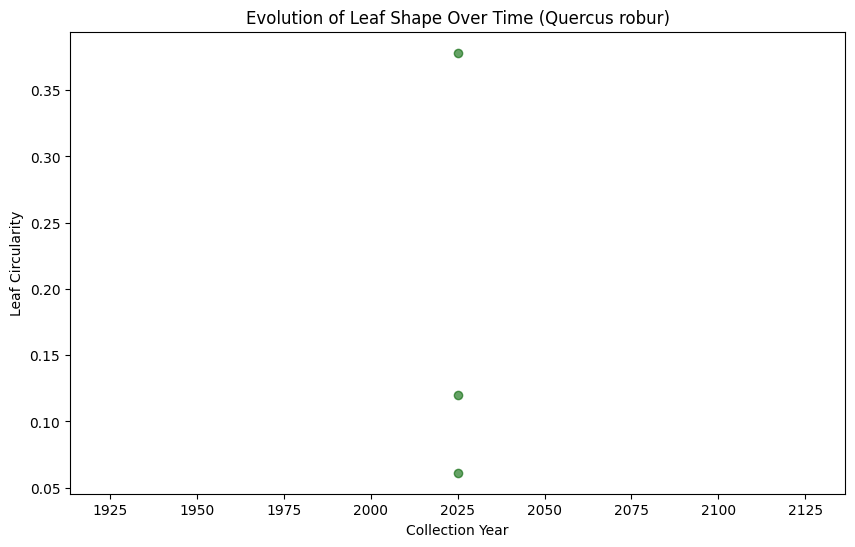

In [88]:
# 1. Drop rows where 'Year' or 'Circularity' is missing
df_clean = df.dropna(subset=['Year', 'Circularity'])

# 2. Force conversion to numeric (this handles any weird string formatting)
df_clean['Year'] = pd.to_numeric(df_clean['Year'])
df_clean['Circularity'] = pd.to_numeric(df_clean['Circularity'])

# 3. Now plot using the clean data
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Year'], df_clean['Circularity'], color='darkgreen', alpha=0.6)
plt.title('Evolution of Leaf Shape Over Time (Quercus robur)')
plt.xlabel('Collection Year')
plt.ylabel('Leaf Circularity')
plt.show()

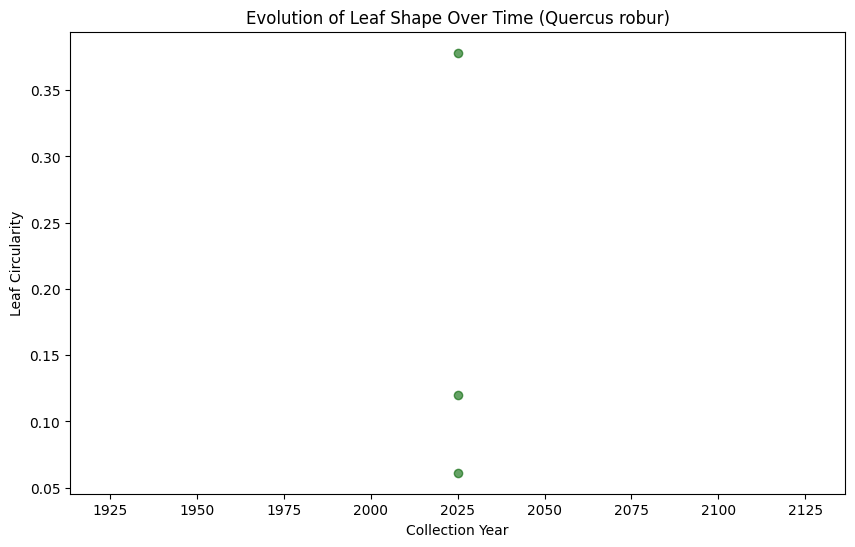

In [89]:
# 1. Drop rows where 'Year' or 'Circularity' is missing
df_clean = df.dropna(subset=['Year', 'Circularity'])

# 2. Force conversion to numeric (this handles any weird string formatting)
df_clean['Year'] = pd.to_numeric(df_clean['Year'])
df_clean['Circularity'] = pd.to_numeric(df_clean['Circularity'])

# 3. Now plot using the clean data
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Year'], df_clean['Circularity'], color='darkgreen', alpha=0.6)
plt.title('Evolution of Leaf Shape Over Time (Quercus robur)')
plt.xlabel('Collection Year')
plt.ylabel('Leaf Circularity')
plt.show()